In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"

In [3]:
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
df = pd.read_csv(f'{DATA_DIR}/v2/function_dataset_v2.csv')

In [5]:
X = df.drop(columns=['id', 'label', 'noise'])
y = df['label']
sample_id = df['id']        # sample_id 不拿去訓練模型

In [6]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [7]:
# 載入最佳模型
best_model = joblib.load(f'{MODEL_DIR}/v2/best_model_v2.joblib')

In [8]:
y_pred = best_model.predict(X_test)

## V2 進階錯誤分析

In [9]:
test_all_df = pd.DataFrame({'id': id_test.values,
                            'label': y_test.values,
                            'predicted_label': y_pred})

In [10]:
# 找出 Logarithmic / Reciprocal 之間的錯誤點
test_df = test_all_df[test_all_df['label'].isin(['logarithmic', 'reciprocal'])].copy()
test_df['error'] = (test_df['label'] != test_df['predicted_label'])

In [11]:
metadata = pd.read_csv(f'{DATA_DIR}/v2/function_metadata_v2.csv')
metadata = metadata[['id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [12]:
test_metadata = metadata.copy()

In [13]:
# 透過樣本編號對應到 metadata
error_metadata = test_df.merge(metadata, on='id', how='left', validate='one_to_one')
test_df = test_df.merge(test_metadata, on='id', how='left', validate='one_to_one')

In [14]:
# V2 錯誤分析的結果
print(f"樣本數: {len(test_df)}")
print(f"預測錯誤: {test_df['error'].sum()}")
print(f"整體錯誤率: {test_df['error'].mean()}")

樣本數: 200
預測錯誤: 60
整體錯誤率: 0.3


In [15]:
print(f"Logarithmic 被誤判成 Reciprocal: {((test_df['label']=='logarithmic') & 
                                          (test_df['predicted_label']=='reciprocal')).sum()}")
type01error = ((y_test == 'logarithmic') & (y_pred == 'reciprocal'))
type01error_index = X_test.index[type01error]
type01error_metadata = error_metadata[(error_metadata['label']=='logarithmic') &
                                      (error_metadata['predicted_label']=='reciprocal')]
print(type01error_metadata[['id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Logarithmic 被誤判成 Reciprocal: 22
  id       label predicted_label   param_1  param_2   param_3  param_4  noise_sigma
2340 logarithmic      reciprocal  1.071804 5.169588 -2.886457      0.0     0.013028
2467 logarithmic      reciprocal -0.390887 6.600218 -1.116584      0.0     0.005486
2417 logarithmic      reciprocal -0.252826 5.161068  0.588994      0.0     0.001835
2187 logarithmic      reciprocal -0.919156 3.174764  2.904468      0.0     0.022943
2033 logarithmic      reciprocal  0.296028 5.289807 -0.178111      0.0     0.005538
2168 logarithmic      reciprocal -0.100000 2.854939  0.605992      0.0     0.004034
2202 logarithmic      reciprocal  0.308827 5.063025 -1.767528      0.0     0.007017
2037 logarithmic      reciprocal  0.116694 3.624111 -0.435824      0.0     0.003349
2206 logarithmic      reciprocal -1.126705 3.441047  2.195805      0.0     0.044695
2218 logarithmic      reciprocal  0.590967 7.752417 -2.639290      0.0     0.003553
2178 logarithmic      reciprocal  0.100000 3

In [16]:
print(f"Reciprocal 被誤判成 Logarithmic: {((test_df['label']=='reciprocal') & 
                                          (test_df['predicted_label']=='logarithmic')).sum()}")
type02error = ((y_test == 'reciprocal') & (y_pred == 'logarithmic'))
type02error_index = X_test.index[type02error]
type02error_metadata = error_metadata[(error_metadata['label']=='reciprocal') &
                                      (error_metadata['predicted_label']=='logarithmic')]
print(type02error_metadata[['id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Reciprocal 被誤判成 Logarithmic: 17
  id      label predicted_label   param_1  param_2   param_3  param_4  noise_sigma
3799 reciprocal     logarithmic  2.898416 5.831440 -1.833281      0.0     0.008026
3940 reciprocal     logarithmic -2.129283 3.513789  0.484736      0.0     0.020284
3997 reciprocal     logarithmic -2.788916 3.135173 -0.289944      0.0     0.055901
3650 reciprocal     logarithmic  1.625112 3.447687 -1.357645      0.0     0.013278
3732 reciprocal     logarithmic -2.467152 3.884066  0.753238      0.0     0.014618
3867 reciprocal     logarithmic  2.847226 5.902157 -0.468339      0.0     0.005250
3772 reciprocal     logarithmic  2.341161 4.511365 -1.374937      0.0     0.004061
3819 reciprocal     logarithmic -2.619313 7.989932  1.451009      0.0     0.003418
3719 reciprocal     logarithmic  2.614034 9.042949  1.085746      0.0     0.001000
3884 reciprocal     logarithmic  1.759714 9.297477  1.190140      0.0     0.002538
3969 reciprocal     logarithmic  1.983924 4.930339 -0.7

In [17]:
# 其他錯誤
others = test_df['error'].sum() - \
    ((test_df['label']=='logarithmic') & (test_df['predicted_label']=='reciprocal')).sum() - \
    ((test_df['label']=='reciprocal') & (test_df['predicted_label']=='logarithmic')).sum()
print(f"其他錯誤: {others}")
other_errors = test_df[(test_df['error']) &
    ~(((test_df['label'] == 'logarithmic') & (test_df['predicted_label'] == 'reciprocal')) |
      ((test_df['label'] == 'reciprocal') & (test_df['predicted_label'] == 'logarithmic')))]
print(other_errors[['id', 'label', 'predicted_label', 'param_1', 
                    'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

其他錯誤: 21
  id       label predicted_label   param_1  param_2   param_3  param_4  noise_sigma
2418 logarithmic          cosine  0.869402 5.163161  0.567110      0.0     0.004802
2267 logarithmic            sine  1.827530 3.573696 -2.947218      0.0     0.058046
3818  reciprocal     exponential -2.583499 3.574078  0.344896      0.0     0.013731
2276 logarithmic     exponential -1.567286 2.118762  1.648271      0.0     0.091247
2320 logarithmic            sine  1.456430 4.858497 -0.045260      0.0     0.022563
3554  reciprocal          linear  2.484573 3.934455  0.769318      0.0     0.005489
2210 logarithmic            sine -0.856315 5.458970  2.799875      0.0     0.004787
3999  reciprocal       quadratic -1.662651 2.592163  0.474439      0.0     0.064086
2277 logarithmic          linear -0.759239 2.586732 -0.740757      0.0     0.030559
2062 logarithmic     exponential  1.801469 3.357334 -1.543531      0.0     0.074907
2110 logarithmic          linear -1.663224 2.758742 -0.387778      

In [18]:
# 顯示 Noise 統計
print(f"Logarithmic → Reciprocal:\n{type01error_metadata['noise_sigma'].describe()}\n")

Logarithmic → Reciprocal:
count    22.000000
mean      0.010662
std       0.013943
min       0.001366
25%       0.003400
50%       0.005625
75%       0.010323
max       0.055977
Name: noise_sigma, dtype: float64



In [19]:
print(f"Reciprocal → Logarithmic:\n{type02error_metadata['noise_sigma'].describe()}\n")

Reciprocal → Logarithmic:
count    17.000000
mean      0.010462
std       0.013489
min       0.001000
25%       0.002965
50%       0.005028
75%       0.013278
max       0.055901
Name: noise_sigma, dtype: float64



In [20]:
bins = [0, 0.02, 0.04, 0.06, 0.08, 0.10, np.inf]      # 將 noise_sigma 分成6個區間
labels = ['0.00 ~ 0.02',
          '0.02 ~ 0.04',
          '0.04 ~ 0.06',
          '0.06 ~ 0.08',
          '0.08 ~ 0.10',
          '0.10+']
test_df['noise_range'] = pd.cut(test_df['noise_sigma'], bins=bins, labels=labels, include_lowest=True)
test_df['error'] = (test_df['label'] != test_df['predicted_label'])     # 判斷是否預測錯誤

In [21]:
# 計算每個 Noise 區間的錯誤率
noise_analysis = test_df.groupby('noise_range', observed=False).agg(total_samples=('error', 'count'),
                                                                    error_count=('error', 'sum'),
                                                                    error_rate=('error', 'mean'))

In [22]:
print(noise_analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))

             total_samples  error_count error_rate
noise_range                                       
0.00 ~ 0.02            160           43     26.88%
0.02 ~ 0.04             22            7     31.82%
0.04 ~ 0.06             12            7     58.33%
0.06 ~ 0.08              4            2     50.00%
0.08 ~ 0.10              1            1    100.00%
0.10+                    1            0      0.00%


C:\Users\user\AppData\Local\Temp\ipykernel_30256\305396495.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


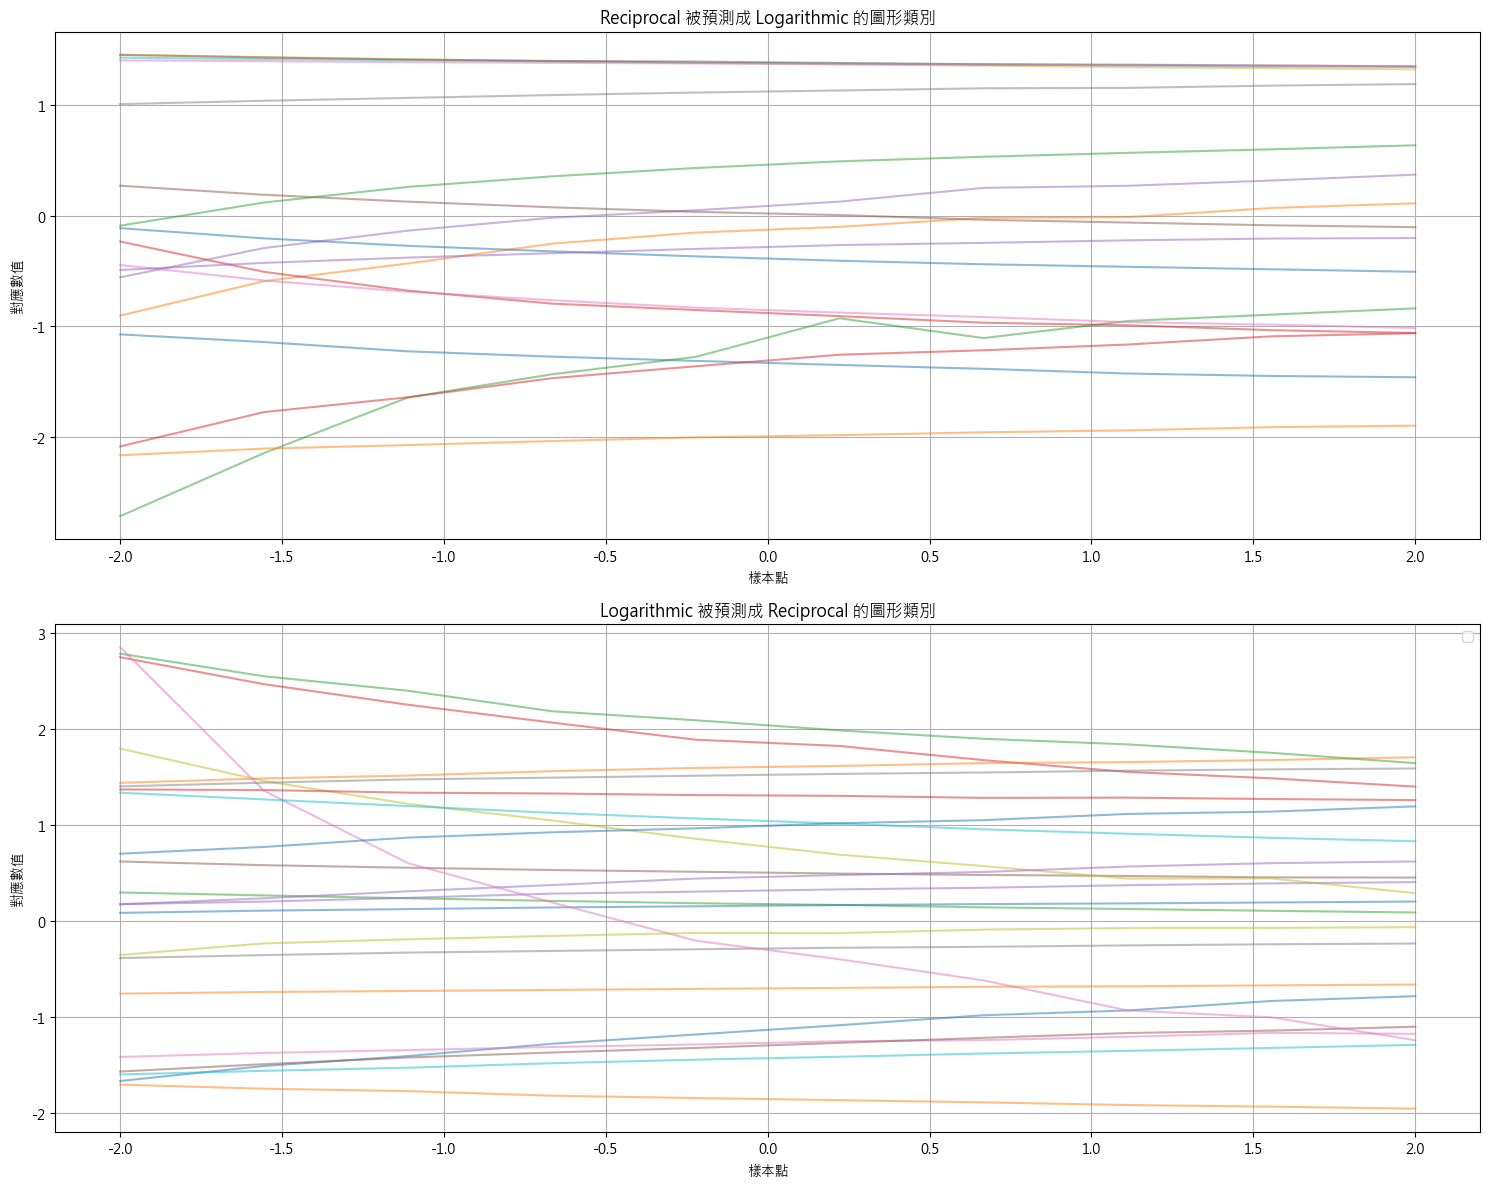

In [23]:
# 繪製圖表
xx = np.linspace(-2, 2, 10)            # Sample Points
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(2, 1, 1)
for index in type02error_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Reciprocal 被預測成 Logarithmic 的圖形類別")
ax.grid()

ax = fig.add_subplot(2, 1, 2)
for index in type01error_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Logarithmic 被預測成 Reciprocal 的圖形類別")
ax.grid()

plt.tight_layout()
plt.legend()
plt.savefig(f'{DATA_DIR}/v2/advanced_error_analysis_v2.png')
plt.show()

### 參數分析

In [24]:
advanced_parameter_summary = []

In [25]:
parameters = ['param_1', 'param_2', 'param_3']
advanced_parameter_summary = []
for parameter in parameters:
    correct_data = test_df[test_df['error'] == False][parameter]
    error_data = test_df[test_df['error'] == True][parameter]
    advanced_parameter_summary.append({'Parameter': parameter,
                                       'Correct Mean': correct_data.mean(), 
                                       'Correct Median': correct_data.median(),
                                       'Error Mean': error_data.mean(),
                                       'Error Median': error_data.median(),
                                       'Mean Difference': (error_data.mean() - correct_data.mean())})
advanced_para_sum_df = pd.DataFrame(advanced_parameter_summary)

In [26]:
print(advanced_para_sum_df.to_string(index=False, 
                                     formatters={'Correct Mean': '{:.3f}'.format,
                                                 'Correct Median': '{:.3f}'.format,
                                                 'Error Mean': '{:.3f}'.format,
                                                 'Error Median': '{:.3f}'.format,
                                                 'Mean Difference': '{:.3f}'.format}))

Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1        0.024          0.132     -0.078        0.101          -0.102
  param_2        5.979          6.060      4.640        3.992          -1.340
  param_3       -0.010         -0.073      0.203        0.352           0.213


In [27]:
# 儲存參數統計比較
advanced_para_sum_df.to_html(f'{DATA_DIR}/v2/advanced_parameter_results_v2.html')

In [28]:
# 分析每個參數的數值區間
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_df[f'{parameter}_range'] = pd.qcut(test_df[parameter], q=4, duplicates='drop')
    analysis = test_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

                  total_samples  error_count error_rate
param_1_range                                          
(-2.908, -1.207]             50           16     32.00%
(-1.207, 0.101]              50           14     28.00%
(0.101, 1.177]               50           17     34.00%
(1.177, 2.952]               50           13     26.00%


                             total_samples  error_count error_rate
param_2_range                                                     
(2.1180000000000003, 3.773]             50           25     50.00%
(3.773, 5.438]                          50           18     36.00%
(5.438, 7.091]                          50           11     22.00%
(7.091, 9.992]                          50            6     12.00%


                  total_samples  error_count error_rate
param_3_range                                          
(-2.996, -1.034]             50           13     26.00%
(-1.034, 0.0825]             50           14     28.00%
(0.0825, 1.194]              50   

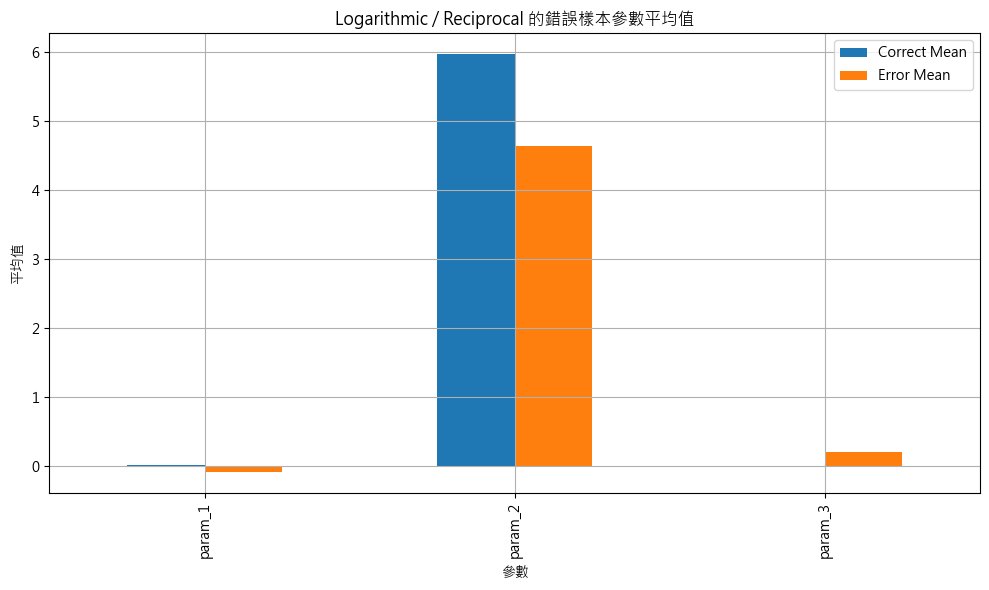

In [29]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = advanced_para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('Logarithmic / Reciprocal 的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.show()